In [1]:
# ============================================
# Import Required Libraries
# ============================================

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Project Directory
BASE_DIR = Path.cwd().parent

# Dataset Path
DATASET_PATH = BASE_DIR / "data" / "Iris.csv"

# Images Folder
IMAGE_PATH = BASE_DIR / "images"
IMAGE_PATH.mkdir(exist_ok=True)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv(DATASET_PATH)

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("Shape :", df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Information")

df.info()

Shape : (150, 6)

Column Names
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_20440\3951044215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


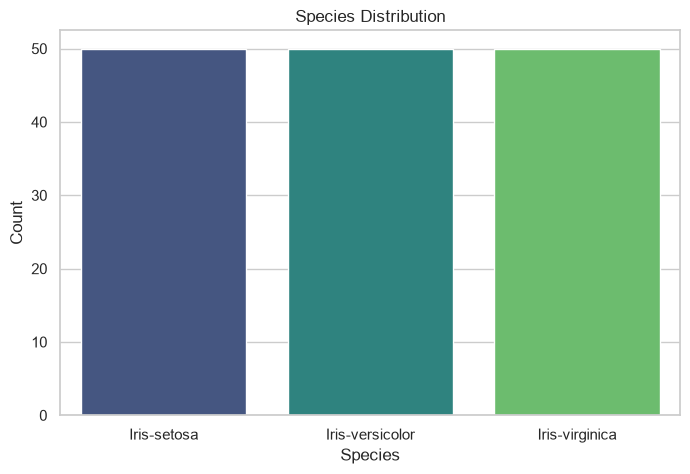

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Species",
    palette="viridis"
)

plt.title("Species Distribution")

plt.xlabel("Species")

plt.ylabel("Count")

plt.savefig(IMAGE_PATH / "species_distribution.png")

plt.show()

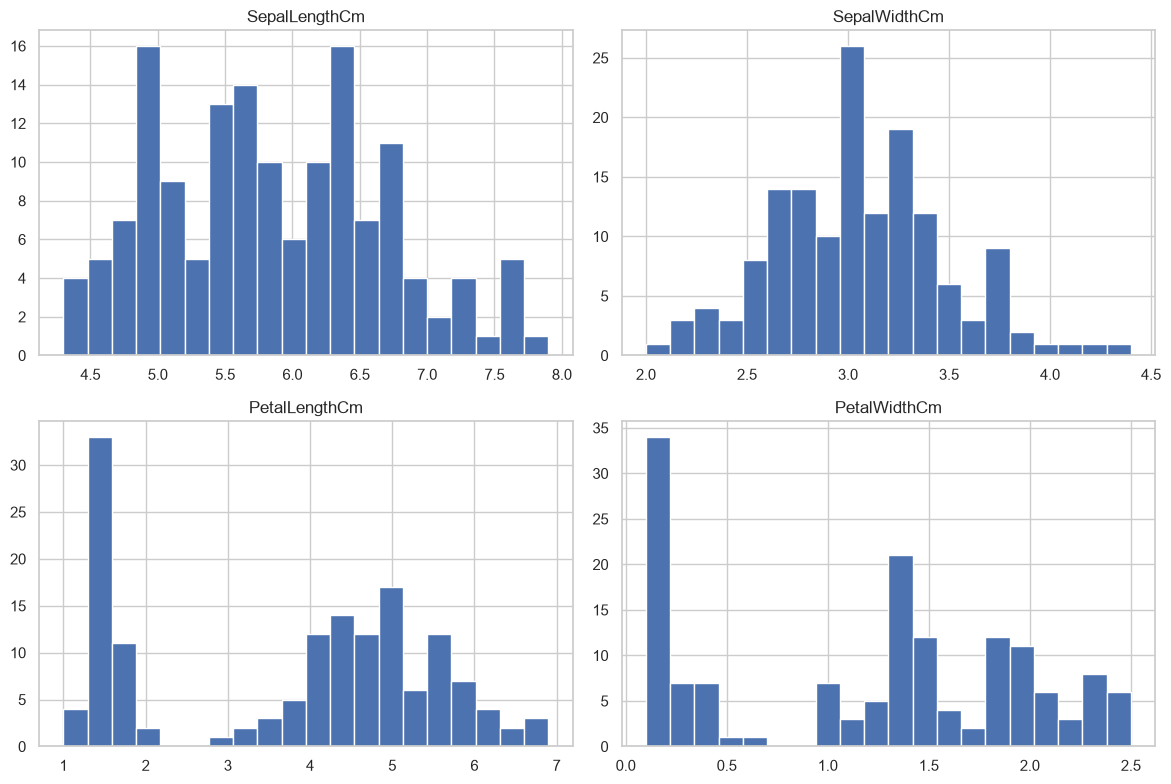

In [8]:
df.drop(columns=["Id"]).hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()

plt.savefig(IMAGE_PATH / "histograms.png")

plt.show()

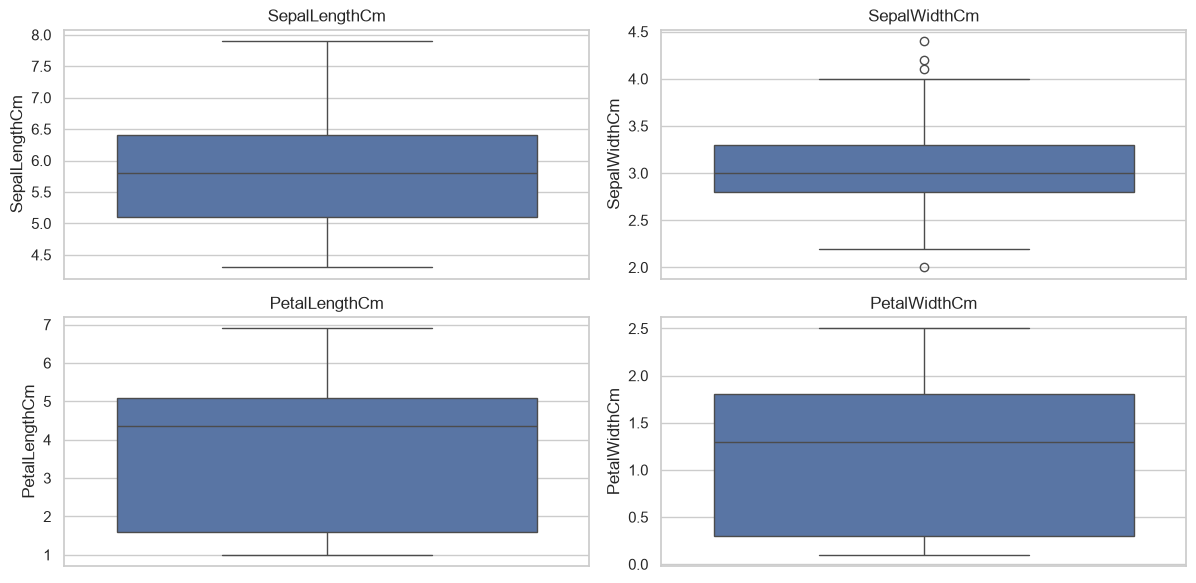

In [9]:
features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

plt.figure(figsize=(12,6))

for i, feature in enumerate(features):

    plt.subplot(2,2,i+1)

    sns.boxplot(y=df[feature])

    plt.title(feature)

plt.tight_layout()

plt.savefig(IMAGE_PATH / "boxplots.png")

plt.show()

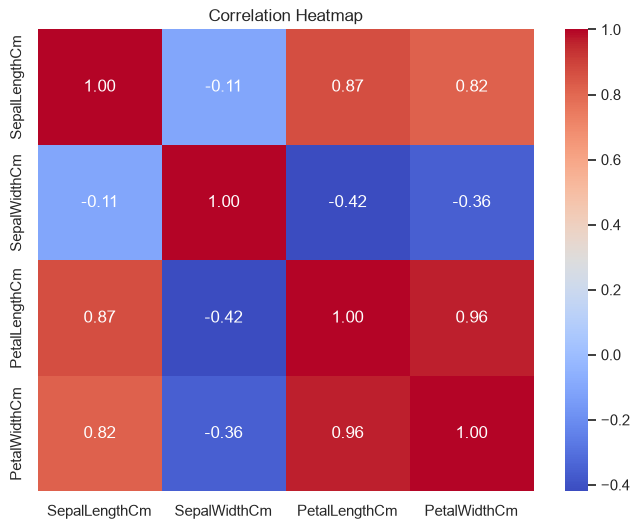

In [10]:
plt.figure(figsize=(8,6))

corr = df.drop(columns=["Id"]).select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(IMAGE_PATH / "heatmap.png")

plt.show()

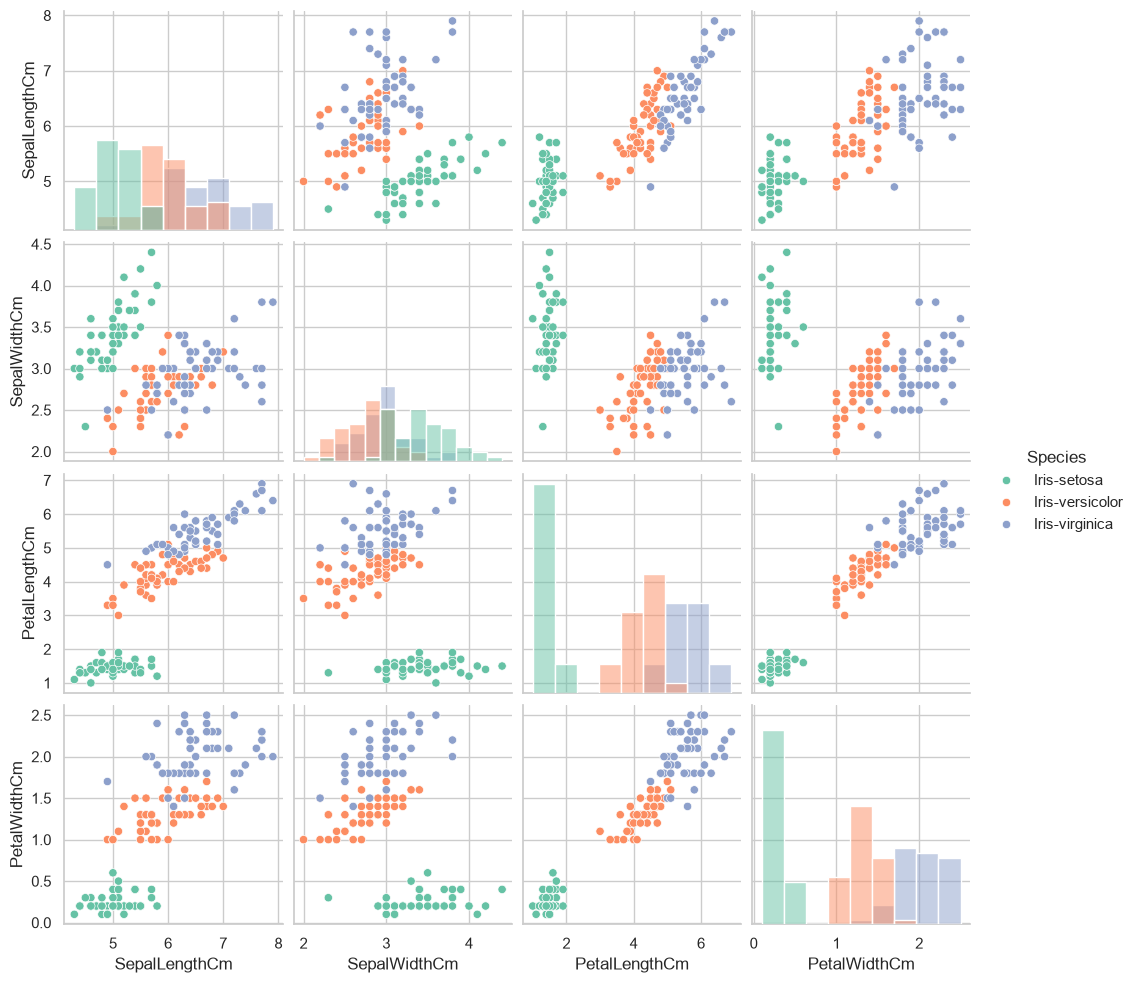

In [11]:
pair = sns.pairplot(
    df.drop(columns=["Id"]),
    hue="Species",
    diag_kind="hist",
    palette="Set2"
)

pair.savefig(IMAGE_PATH / "pairplot.png")

plt.show()